### Objectives
* load story data
* load model
* inference: detect boundaries via local PEs
* consider re-doing other after explicit prompt to detect prediction errors
* consider testing memory

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, glob, os, scipy

from sklearn.metrics.pairwise import cosine_similarity
import torch

### 1. story data

In [2]:
story_csv = pd.read_csv('../ScriptPriming/story_csv/11.csv')

story_txt = ' '.join(story_csv['storyText'].tolist())
sentences = story_csv["storyText"].tolist()
n_sents = len(sentences)

print(f'Extracted entire story, individual sentences, and number of sentences\n')
print(story_txt[:500])
print(sentences[:5])
print(n_sents)

Extracted entire story, individual sentences, and number of sentences

A bell chimed as the door swung open, and Sadie entered to find Thomas, who was dreading the approaching breakup conversation he was about to start, ruminating at the bar. Thomas had been thinking about breaking up with her for 2 months now. The restaurant he had chosen to meet at was reminiscent of a diner from the 70’s. There was black and white checkerboard tiling on the floor, a long bar in the front, and booths and stools with red, leather upholstery.  Thomas stood up and gave Sadie a side 
['A bell chimed as the door swung open, and Sadie entered to find Thomas, who was dreading the approaching breakup conversation he was about to start, ruminating at the bar.', 'Thomas had been thinking about breaking up with her for 2 months now.', 'The restaurant he had chosen to meet at was reminiscent of a diner from the 70’s.', 'There was black and white checkerboard tiling on the floor, a long bar in the front, and boot

### 2. model

In [3]:
%pip install -q transformers accelerate
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
model = model.to(device)

model.eval() # set to evaluation mode (disable dropout, etc.)

print(f"Model loaded: {MODEL_ID}")
print(f"  Layers     : {model.config.num_hidden_layers}\n(+ 1 embedding layer at the beginning that converts raw inputs to tokens)")
print(f"  Hidden dim : {model.config.hidden_size}")


Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Using device: cpu
Model loaded: Qwen/Qwen2.5-0.5B
  Layers     : 24
(+ 1 embedding layer at the beginning that converts raw inputs to tokens)
  Hidden dim : 896


### 3. Perform prediction, grab outputs and activations

Perform next-sentence prediction given n previous sentences

In [4]:
ctxt_window = 7
# next, number of sents for which we can get contextual reps, i.e., have enough history
n_ctxt_sents = n_sents - ctxt_window 
ctxt_sent_rep = {} # each sentence's rep based on preceding context

for ctxt_sent_id in range(n_ctxt_sents):
    
    # tokenize all sents within context
    ctxt_sent_tokens = [tokenizer(sentences[i], return_tensors="pt")["input_ids"][0]
                        for i in range(ctxt_sent_id, ctxt_sent_id + ctxt_window)]
    assert len(ctxt_sent_tokens) == ctxt_window
    
    # stack to form single context token
    ctxt_token = torch.cat(ctxt_sent_tokens).unsqueeze(0).to(device)  # (1, ctxt_window, tokens)

    # inference
    with torch.no_grad(): outputs = model(ctxt_token, output_hidden_states=True)
    # stack layers to get (L+1, total_tokens, hidden)
    hidden = torch.stack(outputs.hidden_states, dim=0).squeeze(1)

    # get the last sentence's token representations
    last_sent_n_tokens = ctxt_sent_tokens[-1].shape[0]
    # avg over tokens and slice only last layer 
    last_sent_rep = hidden[-1, -last_sent_n_tokens:, :].mean(dim=0)  # (hidden)
    
    # add to dict
    ctxt_sent_rep[ctxt_sent_id] = last_sent_rep.cpu().numpy()

assert len(ctxt_sent_rep) == n_ctxt_sents
ctxt_sents_reps = np.stack(list(ctxt_sent_rep.values()))  # (n_ctxt_sents, hidden)
print(f"Context-based sentence representations shape: {ctxt_sents_reps.shape}")


Context-based sentence representations shape: (34, 896)


PE-inducing sentences

In [5]:
def get_bound_ids(predictability_vector):
    

SyntaxError: incomplete input (1778785765.py, line 2)

Plots

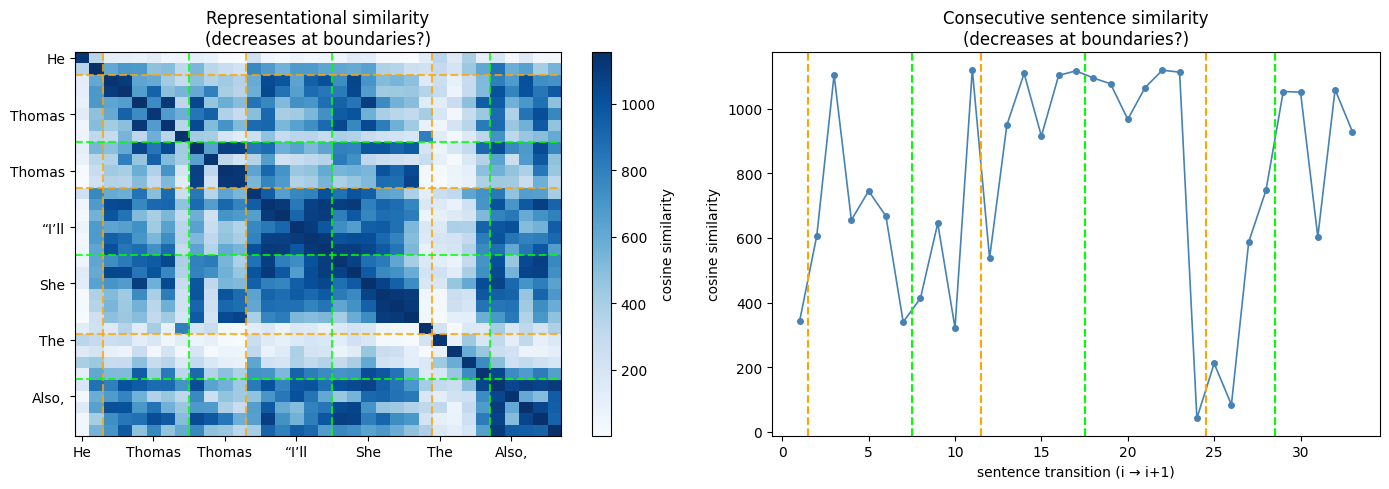

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1
ax = axs[0]
ax.set(title="Representational similarity\n(decreases at boundaries?)",
       xticks=range(0, n_ctxt_sents, 5),
       yticks=range(0, n_ctxt_sents, 5),
       xticklabels=[sentences[i + ctxt_window - 1].split()[0] for i in range(0, n_ctxt_sents, 5)],
       yticklabels=[sentences[i + ctxt_window - 1].split()[0] for i in range(0, n_ctxt_sents, 5)])
reps_similarity = cosine_similarity(ctxt_sents_reps)
reps_similarity = scipy.stats.rankdata(reps_similarity).reshape(n_ctxt_sents, n_ctxt_sents) # rank
im = ax.imshow(reps_similarity, aspect="auto", cmap="Blues", vmin=np.min(reps_similarity), vmax=np.max(reps_similarity))
plt.colorbar(im, ax=ax, label="cosine similarity")

# overlay event boundaries (locationEvent changes)
loc_bounds = np.where(np.diff(story_csv["locationEvent"].values[ctxt_window-1:].astype(int)) != 0)[0] + 0.5
soc_bounds = np.where(np.diff(story_csv["socialEvent"].values[ctxt_window-1:].astype(int)) != 0)[0] + 0.5
for lb in loc_bounds:
    ax.axvline(lb, color="orange", lw=1.5, linestyle="--", alpha=0.8)
    ax.axhline(lb, color="orange", lw=1.5, linestyle="--", alpha=0.8)
for sb in soc_bounds:
    ax.axvline(sb, color="lime", lw=1.5, linestyle="--", alpha=0.8)
    ax.axhline(sb, color="lime", lw=1.5, linestyle="--", alpha=0.8)

# 2
ax = axs[1]
ax.set(title="Consecutive sentence similarity\n(decreases at boundaries?)",
       xlabel="sentence transition (i → i+1)", ylabel="cosine similarity")
consec_sent_sim = np.array([reps_similarity[i, i+1] for i in range(n_ctxt_sents - 1)])
#
ax.plot(range(1, n_ctxt_sents), consec_sent_sim, marker="o", ms=4, color="steelblue", lw=1.2)
#

for lb in loc_bounds:
    ax.axvline(lb, color="orange", lw=1.5, linestyle="--", label="loc. boundary" if lb == loc_bounds[0] else "")
for sb in soc_bounds:
    ax.axvline(sb, color="lime", lw=1.5, linestyle="--", label="soc. boundary" if sb == soc_bounds[0] else "")

plt.tight_layout()
plt.show()

# # print corr between surprisal and consecutive sentence similarity
# corr = np.corrcoef(consec_sent_sim, surprisals)[0, 1]
# print(f"Correlation between consecutive sentence similarity and surprisal: {corr:.3f}")

# delta_norms = np.linalg.norm(np.diff(reps_similarity, axis=0), axis=1)
# print(f"Correlation between rep-shift magnitude and surprisal: {np.corrcoef(delta_norms, surprisals)[0,1]:.3f}")


Compute behavioral measure of surprisal

In [ ]:
# import torch.nn.functional as F

# def next_sentence_surprisal(sentences, model, tokenizer, device):
#     """
#     Compute mean per-token NLL of sentence[i+1] given sentence[i] as context.
#     Returns np.ndarray of shape (n_sents - 1,) in nats/token.
#     """
#     surprisals = []
#     for i in range(len(sentences) - 1):
#         context_ids = tokenizer(sentences[i], return_tensors="pt")["input_ids"][0]
#         target_ids  = tokenizer(sentences[i+1], return_tensors="pt")["input_ids"][0]
#         # full input: [context | target]; only score target tokens
#         input_ids = torch.cat([context_ids, target_ids]).unsqueeze(0).to(device)
#         n_ctx = len(context_ids)
#         with torch.no_grad():
#             logits = model(input_ids).logits[0]  # (seq_len, vocab)
#         # target tokens are at positions n_ctx..end; their logits are at n_ctx-1..end-1 (causal shift)
#         target_logits = logits[n_ctx - 1 : n_ctx - 1 + len(target_ids)]
#         nll = F.cross_entropy(target_logits, target_ids.to(device), reduction="mean")
#         surprisals.append(nll.item())
#     return np.array(surprisals)

# surprisals = next_sentence_surprisal(sentences, model, tokenizer, device)
# print(f"surprisals shape: {surprisals.shape},  first 5: {surprisals[:5].round(3)}")


### 5. [TODO] task-prompted extraction — prediction-error based boundaries

The idea: prime the model with a system prompt asking it to predict the next sentence.  
The **prediction error** at sentence *i* is approximated by:  
`1 - cosine_similarity(predicted_rep(i), actual_rep(i+1))`  
where `predicted_rep(i)` = hidden state when the model reads sentence *i* under the boundary-detection prompt.

Run the same PCA/cosine-similarity pipeline on the prompted reps to compare.


In [ ]:

BOUNDARY_PROMPT = (
    "You are reading a story one sentence at a time. "
    "After each sentence, predict what comes next and flag if a major narrative "
    "event boundary (location change or social change) has just occurred."
)

def get_prompted_hidden_states(sentences, model, tokenizer, device, system_prompt=BOUNDARY_PROMPT):
    """
    Extract hidden states sentence by sentence, each time prepending the full
    prior context + system prompt so the model carries a running narrative.

    Returns
    -------
    np.ndarray, shape (n_sentences, n_layers+1, hidden_dim)
    """
    all_hs = []
    context = system_prompt + "\n\n"
    for sent in sentences:
        prompt = context + "Sentence: " + sent + "\nNext:"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden = torch.stack(outputs.hidden_states, dim=0).squeeze(1)  # (L+1, seq, hidden)
        # take the last token (generation position) as the "prediction" rep
        last_tok = hidden[:, -1, :]  # (L+1, hidden)
        all_hs.append(last_tok.cpu().numpy())
        context += "Sentence: " + sent + "\n"
    return np.stack(all_hs, axis=0)  # (n_sent, L+1, hidden)


# Uncomment to run (slower — processes full growing context per sentence):
prompted_hidden = get_prompted_hidden_states(sentences, model, tokenizer, device)
print("prompted_hidden shape:", prompted_hidden.shape)

# prediction error: 1 - cosine_sim(prompted_rep[i, last_layer], plain_rep[i+1, last_layer])
from sklearn.metrics.pairwise import cosine_similarity as cossim
pred_err = [
    1 - cossim(prompted_hidden[i, -1:, :], hidden_states[i+1, -1:, :])[0, 0]
    for i in range(len(sentences) - 1)
]
plt.figure(figsize=(10, 3))
plt.plot(pred_err, marker="o", ms=4)
plt.title("Prediction error per sentence transition (prompted model)")
plt.xlabel("sentence transition"); plt.ylabel("1 - cosine sim")
plt.tight_layout(); plt.show()


prompted_hidden shape: (41, 25, 896)


NameError: name 'hidden_states' is not defined